# UTA_DIS

## functions and classes:

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple

from functools import partial
from typing import Any, Tuple
import numpy as np
import torch
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from sklearn.metrics import f1_score


import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
import os

#### models

In [33]:
class CriterionLayerCombine(nn.Module):
    """
    Custom module to combine outputs from all hidden components.

    Args:
        num_criteria (int): Number of criteria.
        num_hidden_components (int): Number of hidden components.
        min_weight (float, optional): Minimum weight value. Defaults to 0.001.
    """

    def __init__(
        self,
        num_criteria: int,
        num_hidden_components: int,
        min_weight: float = 0.001,
        **kwargs
    ):
        super().__init__()
        self.min_weight = min_weight
        self.weight = nn.Parameter(
            torch.FloatTensor(num_hidden_components, num_criteria)
        )
        self.reset_parameters()

    def reset_parameters(self) -> None:
        """
        Reset the parameters of the module.
        """
        nn.init.uniform_(self.weight, 0.2, 1.0)
        self.weight.data = self.weight.data / torch.sum(self.weight.data)

    def compute_weight(self) -> torch.Tensor:
        """
        Compute the weight value.

        Returns:
            torch.Tensor: Weight value.
        """
        with torch.no_grad():
            self.weight.data[self.weight.data < 0] = self.min_weight
        return self.weight

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the module.

        Args:
            input (torch.Tensor): Input tensor of shape (batch_size, num_hidden_components, num_criteria).

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, num_criteria).
        """
        return (input * self.compute_weight()).sum(1)

In [34]:
class CriterionLayerSpread(nn.Module):
    """
    Custom module for spreading the input value to all hidden components.

    Args:
        num_criteria (int): Number of criteria.
        num_hidden_components (int): Number of hidden components.
        input_range (Tuple[float, float], optional): Range of input values. Defaults to (0, 1).
        normalize_bias (bool, optional): Flag to normalize the bias. Defaults to False.
    """

    def __init__(
        self,
        num_criteria: int,
        num_hidden_components: int,
        input_range: Tuple[float, float] = (0, 1),
        normalize_bias: bool = False,
        **kwargs
    ) -> None:
        super().__init__()
        self.num_criteria = num_criteria
        input_range = (-input_range[0], -input_range[1])
        self.max_bias = max(input_range)
        self.min_bias = min(input_range)
        self.normalize_bias = normalize_bias
        self.bias = nn.Parameter(torch.FloatTensor(num_hidden_components, num_criteria))
        self.weight = nn.Parameter(
            torch.FloatTensor(num_hidden_components, num_criteria)
        )
        self.reset_parameters()
        self.min_w = 0

    def reset_parameters(self) -> None:
        """
        Reset the parameters of the module.
        """
        nn.init.uniform_(self.weight, 1, 10.0)
        nn.init.uniform_(self.bias, self.min_bias, self.max_bias)

    def compute_bias(self) -> torch.Tensor:
        """
        Compute the bias value.

        Returns:
            torch.Tensor: Bias value.
        """
        if self.normalize_bias:
            return torch.clamp(self.bias, self.min_bias, self.max_bias)
        else:
            return self.bias

    def compute_weight(self) -> torch.Tensor:
        """
        Compute the weight value.

        Returns:
            torch.Tensor: Weight value.
        """
        # return torch.clamp(self.weight, 0.0)
        with torch.no_grad():
            self.weight.data[self.weight.data < 0] = self.min_w
        return self.weight

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the module.

        Args:
            input (torch.Tensor): Input tensor of shape (batch_size, num_criteria).

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, num_hidden_components, num_criteria).
        """
        x = input.view(-1, 1, self.num_criteria)
        return (x + self.compute_bias()) * self.compute_weight()


In [35]:
class LeakyHardSigmoid(nn.Module):
    """
    Custom module for LeakyHardSigmoid activation function.

    Args:
        slope (float, optional): Slope value for function. Defaults to 0.01.
    """

    def __init__(self, slope: float = 0.01, **kwargs):
        super().__init__()
        self.slope = slope

    def set_slope(self, val: float) -> None:
        """
        Set the slope value for the function.

        Args:
            val (float): Slope value.
        """
        self.slope = val

    def forward(self, input):
        """
        Forward pass of the module.

        Args:
            input (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor.
        """
        return F.leaky_relu(1.0 - F.leaky_relu(1 - input, self.slope), self.slope)

In [36]:
class MonotonicLayer(nn.Sequential):
    """
    Custom module for Monotonic layer.

    Args:
        num_criteria (int): Number of criteria.
        num_hidden_components (int): Number of hidden units.
        slope (float, optional): Slope value for LeakyHardSigmoid. Defaults to 0.01.
    """

    def __init__(
        self,
        num_criteria: int,
        num_hidden_components: int,
        slope: float = 0.01,
        **kwargs
    ):
        super().__init__()
        self.criterion_layer_spread = CriterionLayerSpread(
            num_criteria, num_hidden_components, **kwargs
        )
        self.activation_function = LeakyHardSigmoid(slope=slope, **kwargs)
        self.criterion_layer_combine = CriterionLayerCombine(
            num_criteria, num_hidden_components, **kwargs
        )

    def set_slope(self, val: float) -> None:
        """
        Set the slope value for the LeakyHardSigmoid activation function.

        Args:
            val (float): Slope value.
        """
        self.activation_function.set_slope(val)

    def forward(self, x):
        """
        Forward pass of the module.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, num_criteria).

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, num_criteria).
        """
        for module in self._modules.values():
            x = module(x)
        return x

In [37]:
class Uta(nn.Sequential):
    """
    Custom module for Uta network.

    Args:
        num_criteria (int): Number of criteria.
        num_hidden_components (int): Number of hidden components of monotonic block.
        slope (float, optional): Slope value for LeakyHardSigmoid. Defaults to 0.01.
    """

    def __init__(
        self,
        num_criteria: int,
        num_hidden_components: int,
        slope: float = 0.01,
        **kwargs
    ):
        super().__init__()
        self.monotonic_layer = MonotonicLayer(
            num_criteria, num_hidden_components, slope, **kwargs
        )

    def set_slope(self, val: float) -> None:
        """
        Set the slope value for the LeakyHardSigmoid activation function.

        Args:
            val (float): Slope value.
        """
        self.monotonic_layer.set_slope(val)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the module.

        Args:
            input (torch.Tensor): Input tensor of shape (batch_size,  num_criteria).

        Returns:
            torch.Tensor: Output tensor.
        """
        x = self.monotonic_layer(input)
        return x.sum(1)

In [38]:
class ThresholdLayer(nn.Module):
    """A threshold layer that subtracts a threshold from the input tensor.
    Alternatives from class 1 should have utility greater than the threshold.
    Alternatives from class 0 should have utility less than the threshold.

    """

    def __init__(self, threshold: float = None, requires_grad: bool = False):
        """Initialize the threshold layer.

        Args:
            threshold (float, optional): The threshold value. Defaults to None.
                If None, the threshold is initialized randomly.
            requires_grad (bool, optional): Whether the threshold should be trainable.
                Defaults to True.
        """
        super().__init__()
        if threshold is None:
            self.threshold = nn.Parameter(
                torch.FloatTensor(1).uniform_(0.1, 0.9), requires_grad=requires_grad
            )
        else:
            self.threshold = nn.Parameter(
                torch.FloatTensor([threshold]), requires_grad=requires_grad
            )

    def forward(self, x: torch.FloatTensor) -> torch.FloatTensor:
        """Forward pass of the threshold layer.

        Args:
            x (torch.FloatTensor): Input tensor.

        Returns:
            torch.FloatTensor: Output tensor.
        """
        return x - self.threshold

In [39]:
class NormLayer(nn.Module):
    """
    Custom module for min-max normalization layer.

    This normalization layer performs min-max normalization on the input tensor,
    such that if all criteria are equal to 0, the output is 0, and if all criteria
    are equal to 1, the output is 1.
    Additionally, the output is thresholded using a ThresholdLayer with a threshold of 0.5.

    Args:
        method_instance (torch.nn.Module): Instance of the method to be normalized.
        num_criteria (int): Number of criteria.
    """

    def __init__(self, method_instance: torch.nn.Module, num_criteria: int):
        super().__init__()
        self.method_instance = method_instance
        self.num_criteria = num_criteria
        self.thresholdLayer = ThresholdLayer(0.5)

    def set_slope(self, slope: float):
        """
        Set the slope value for the LeakyHardSigmoid activation function.

        Args:
            val (float): Slope value.
        """
        self.method_instance.set_slope(slope)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the module.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor.
        """
        self.out = self.method_instance(input)

        zero_input = torch.zeros(self.num_criteria).view(1, 1, -1).to(self.out.device)
        zero = self.method_instance(zero_input)
        one = self.method_instance(zero_input + 1)

        self.out = (self.out - zero) / (one - zero)
        return self.thresholdLayer(self.out)

#### utils

In [40]:
from functools import partial
from typing import Any, Tuple

import numpy as np
import torch
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm


class Hook:
    """A class to store a hook for a model."""

    def __init__(self, layer: torch.nn.Module, func: callable):
        """Constructor for the Hook class. Registers a hook on the given model layer.

        Args:
            layer (torch.nn.Module): The layer to register the hook on.
            func (callable): The function to call when the hook is triggered.
        """
        self.hook = layer.register_forward_hook(partial(func, self))

    def remove(self):
        """
        Remove the hook from the model.
        """
        self.hook.remove()

    def __del__(self):
        """Destructor for the Hook class. Removes the hook from the model."""
        self.remove()


def append_output(hook: Hook, mod: torch.nn.Module, input: Any, output: torch.Tensor):
    """Append the output of the layer to the hook."""
    if not hasattr(hook, "stats"):
        hook.stats = []
    if not hasattr(hook, "name"):
        hook.name = mod.__class__.__name__
    data = hook.stats
    data.append(output.data)


def get_simple_input(val: float, num_criteria: int) -> torch.Tensor:
    """
    Creates a simple input tensor with the provided value for all criteria.

    Args:
        val (float): The value to fill the tensor with.
        num_criteria (int): The number of criteria (dimensions) in the tensor.

    Returns:
        torch.Tensor: The created input tensor with shape (1, 1, num_criteria).
    """

    input_tensor = torch.full((1, 1, num_criteria), val, dtype=torch.float)
    return input_tensor.cpu()


class NumpyDataset(Dataset):
    """A class to create a PyTorch dataset from numpy arrays."""

    def __init__(self, data: np.array, targets: np.array):
        """Constructor for the NumpyDataset class.

        Args:
            data (np.array): Input data (features).
            targets (np.array): Target data (labels).
        """
        self.data = torch.Tensor(data)
        self.targets = torch.LongTensor(targets.astype(int))

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Get the item at the given index.

        Args:
            index (int): The index of the item to get.

        Returns:
            tuple(torch.Tensor, torch.Tensor): The input data and target data at the given index.
        """
        x = self.data[index]
        y = self.targets[index]
        return x, y

    def __len__(self) -> int:
        """Get the length of the dataset."""
        return len(self.data)


def CreateDataLoader(data: np.array, targets: np.array) -> DataLoader:
    """Create a DataLoader from the given data and targets.

    Args:
        data (np.array): Input data (features).
        targets (np.array): Target data (labels).

    Returns:
        DataLoader: A DataLoader containing the given data and targets.
    """
    dataset = NumpyDataset(data, targets)
    return DataLoader(dataset, batch_size=len(dataset))


def Regret(output: torch.FloatTensor, target: torch.LongTensor, weight= 1.0) -> torch.FloatTensor:
    """Calculate the regret loss between the output and target tensors.
    For each alternative that is in class 1 the output should be positive, so negative values are penalized.
    For each alternative that is in class 0 the output should be negative, so positive values are penalized.

    Args:
        output (torch.FloatTensor): Output tensor from the model.
        target (torch.LongTensor): Target tensor.

    Returns:
        torch.FloatTensor: The regret loss between the output and target tensors.
    """
    return torch.mean(
        F.relu(-(target >= 1).float() * output) + weight * F.relu((target < 1).float() * output)
    )


def Accuracy(output: torch.FloatTensor, target: torch.LongTensor) -> torch.FloatTensor:
    """Calculate the accuracy of the model output compared to the target tensor.

    Args:
        output (torch.FloatTensor): Output tensor from the model.
        target (torch.LongTensor): Target tensor.

    Returns:
        torch.FloatTensor: The accuracy of the model output compared to the target tensor.
    """
    return (target == (output > 0) * 1).detach().numpy().mean()


def AUC(output: torch.FloatTensor, target: torch.LongTensor) -> torch.FloatTensor:
    """Calculate the AUC score of the model output compared to the target tensor.

    Args:
        output (torch.FloatTensor): Output tensor from the model.
        target (torch.LongTensor): Target tensor.

    Returns:
        torch.FloatTensor: The AUC score of the model output compared to the target tensor.
    """
    return roc_auc_score(target.detach().numpy(), output.detach().numpy())

def F1(output: torch.FloatTensor, target: torch.LongTensor) -> torch.FloatTensor:
    """Calculate the F1 score of the model output compared to the target tensor.

    Args:
        output (torch.FloatTensor): Output tensor from the model.
        target (torch.LongTensor): Target tensor.

    Returns:
        torch.FloatTensor: The F1 score of the model output compared to the target tensor.
    """

    pred = (output > 0).int().detach().numpy()
    true = target.detach().numpy()
    return np.float64(f1_score(true, pred))  

class ScoreTracker:
    def __init__(self):

        self.losses = []
        self.auc_scores = []
        self.acc_scores = []
        self.F1 = []

    def append(self, loss: float, auc: float, acc: float, f1:float) -> None:
        """
        Append the given loss, auc, and acc scores to the respective lists.

        Args:
            loss (float): The loss score to append.
            auc (float): The AUC score to append.
            acc (float): The accuracy score to append.
        """
        self.losses.append(loss)
        self.auc_scores.append(auc)
        self.acc_scores.append(acc)
        self.F1.append(f1)

    def add(self, outputs: torch.FloatTensor, labels: torch.LongTensor, weight) -> None:
        """Calculate and append the loss, auc, and acc scores for the given model outputs
            and ground truth labels.

        Args:
            outputs (torch.FloatTensor): The model outputs.
            labels (torch.LongTensor): The ground truth labels.
        """
        self.losses.append(Regret(outputs, labels, weight))
        self.auc_scores.append(AUC(outputs, labels))
        self.acc_scores.append(Accuracy(outputs, labels))
        self.F1.append(F1(outputs, labels))


def Train(
    model: torch.nn.Module,
    train_dataloader: DataLoader,
    test_dataloader: DataLoader,
    path: str,
    lr: float = 0.01,
    epoch_nr: int = 200,
    slope_decrease: bool = False,
    weight = 1.0,
) -> Tuple[float, float, ScoreTracker, ScoreTracker]:
    """Train the given model using the given training and test dataloaders.

    Args:
        model (torch.nn.Module): The model to train.
        train_dataloader (DataLoader): The dataloader containing the training data.
        test_dataloader (DataLoader): The dataloader containing the test data.
        path (str): The path to save the model.
        lr (float, optional): The learning rate for the optimizer. Defaults to 0.01.
        epoch_nr (int, optional): The number of epochs to train the model. Defaults to 200.
        slope_decrease (bool, optional): Whether to decrease the slope of the leaky hard sigmoid.

    Returns:
        tuple(float, float, ScoreTracker, ScoreTracker): A tuple containing the best accuracy,
            best AUC score, training stats, and test stats.
    """

    optimizer = optim.AdamW(
        model.parameters(), lr=lr, betas=(0.9, 0.99), weight_decay=0.01
    )
    # Add a learninge rate scheduler to the optimizer
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, steps_per_epoch=len(train_dataloader), epochs=epoch_nr
    )
    best_acc = 0.0
    best_auc = 0.0
    best_F1 = 0.0
    stats_train = ScoreTracker()
    stats_test = ScoreTracker()
    # Decrease the slope of the leaky hard sigmoid activation function in each epoch
    slopes = np.linspace(0.01, 0.003, epoch_nr)
    for epoch in tqdm(range(epoch_nr)):
        if slope_decrease:
            model.set_slope(slopes[epoch])
        for _, data in enumerate(train_dataloader, 0):
            inputs, labels = data
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = Regret(outputs, labels, weight)
            loss.backward()
            optimizer.step()
            scheduler.step()
            acc = Accuracy(outputs, labels)
            auc = AUC(outputs, labels)
            F1_score = F1(outputs, labels)
            stats_train.append(float(loss), float(auc), float(acc), float(F1_score))        
        with torch.no_grad():
            for _, data in enumerate(test_dataloader, 0):
                inputs, labels = data
                outputs = model(inputs)
                stats_test.add(outputs, labels, weight)

        # Save the model if the accuracy is better than the previous best
        if acc > best_acc:
            best_acc = acc
            best_auc = auc
            best_F1 = F1_score

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                },
                path,
            )

    return (
        best_acc,
        best_auc,
        best_F1,
        stats_train,
        stats_test,
    )

## main

### model loading:

In [41]:
# Load data, split into train and test sets and create dataloaders
os.makedirs("models", exist_ok=True)

data_path = os.path.join("dataset_refining", "german_credit_data_with_risk.csv")
data = pd.read_csv(data_path, header=0)
data['Saving accounts'] = data['Saving accounts'].fillna(4) # missing value present when no saving account is present -> mostly companies and therefore indicates higher performance
data['Checking account'] = data['Checking account'].fillna(3) # similarly here

data.drop(columns= ['Sex', ], inplace=True) # judging by sex should be not relevant to prevent alligations of being sexist

data.replace({'Checking account': {'little': 1, 'moderate': 2, 'rich': 3}}, inplace=True)
data.replace({'Saving accounts':{'little': 0, 'moderate': 1, 'quite rich': 2, 'rich': 3}}, inplace=True)
# data.replace({'Housing': {'own': 2, 'rent': 1, 'free': 0}}, inplace=True)
# data.replace({'Sex' : {'male': 0, 'female': 1}}, inplace=True)
data.drop(columns=[ 'Housing', 'Job'], inplace=True) 
data['credit_risk'] = data['credit_risk'].map({1: 1, 2: 0})
labels_map = {1: "low risk", 0: "high risk"}
data['Credit amount'] = -data['Credit amount']

purpose_map = {
    "radio/TV": 0,
    "car": 0,
    "vacation/others": 0,
    "furniture/equipment": 1,
    "repairs": 1,
    'domestic appliances': 1,
    "education": 2,
    "business": 2
}
data["Purpose"] = data["Purpose"].map(purpose_map)
data["Duration"] = -data["Duration"]



In [42]:
data #after preprocessing

,Age,Saving accounts,Checking account,Credit amount,Duration,Purpose,credit_risk
0,67,4,1,-1169,-6,0,1
1,22,0,2,-5951,-48,0,0
2,49,0,3,-2096,-12,2,1
3,45,0,1,-7882,-42,1,1
4,53,0,1,-4870,-24,0,0
...,...,...,...,...,...,...,...
995,31,0,3,-1736,-12,1,1
996,40,0,1,-3857,-30,0,1
997,38,0,3,-804,-12,0,1
998,23,0,1,-1845,-45,0,0


In [43]:
from sklearn.preprocessing import MinMaxScaler

num_criteria = 6
data_input = data.iloc[:, :num_criteria]
columns = data.columns
data_target = data[columns[num_criteria]]

data_input = data.iloc[:, :num_criteria].values
data_target = data['credit_risk'].values

# Normalize to [0, 1]
scaler = MinMaxScaler() # current model version accepts values in range 0-1, due to the nature of the model normalisation should not influence the quality of predictions
data_input = scaler.fit_transform(data_input.reshape(-1, num_criteria))
data_input = data_input.reshape(-1, 1, num_criteria)


X_train, X_test, y_train, y_test = train_test_split(
    data_input, data_target, test_size=0.2, random_state=42
)



train_dataloader = CreateDataLoader(X_train, y_train)
test_dataloader = CreateDataLoader(X_test, y_test)

In [44]:
SEED = 44
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [45]:
SAVE_PATH = "models/cnn_utadis_model.pth"
# Create model and train
uta = Uta(num_criteria, 30)
model = NormLayer(uta, num_criteria)
weight_pos = (y_train == 0).sum() / (y_train == 1).sum()
(
    best_acc,
    best_auc,
    best_F1,
    stats_train,
    stats_test,
) = Train(model, train_dataloader, test_dataloader, SAVE_PATH,epoch_nr=500,lr =0.0001,slope_decrease=True, weight = weight_pos)

100%|██████████| 500/500 [00:17<00:00, 27.96it/s]


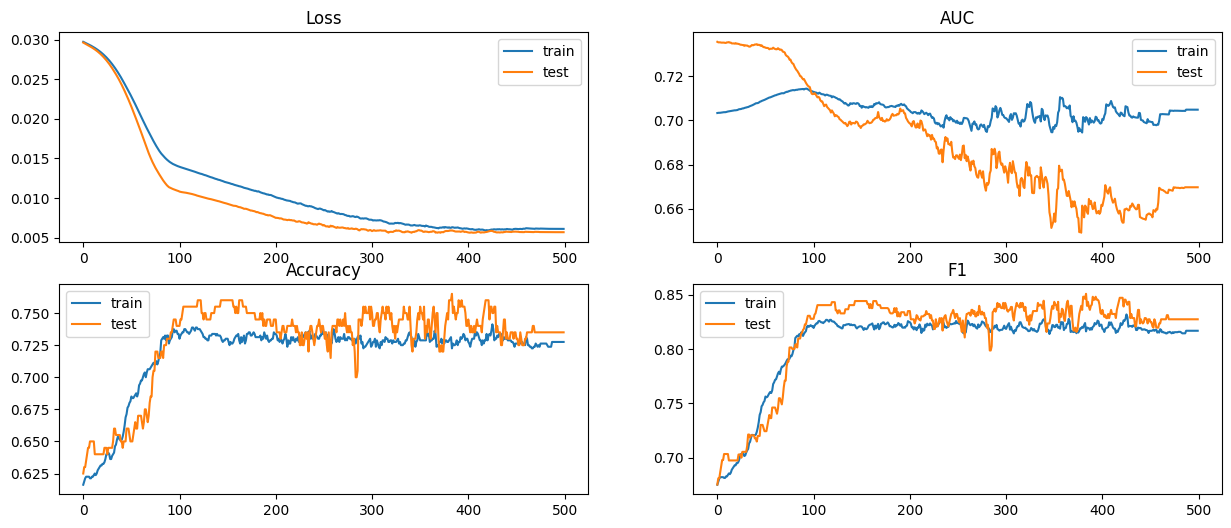

In [46]:
# Plot results
fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(2,2,1)
ax.plot(stats_train.losses,label='train')
ax.plot(stats_test.losses,label='test')
ax.set_title('Loss')
ax.legend()

ax = fig.add_subplot(2,2,2)
ax.plot(stats_train.auc_scores,label='train')
ax.plot(stats_test.auc_scores,label='test')
ax.set_title('AUC')
ax.legend()

ax = fig.add_subplot(2,2,3)
ax.plot(stats_train.acc_scores,label='train')
ax.plot(stats_test.acc_scores,label='test')
ax.set_title('Accuracy')
ax.legend()

ax = fig.add_subplot(2,2,4)
ax.plot(stats_train.F1,label='train')
ax.plot(stats_test.F1,label='test')
ax.set_title('F1')
ax.legend()

the loss is decreasing for the whole training, and stabilises at the end, but quality of predictions improves only at the beggining of training, there are no signs of overfitting, test performance is often even better than train performance. there is no need to decrease number of piecewise linear parts that are contained in each marginal function

In [47]:
# Load model from checkpoint
checkpoint = torch.load(SAVE_PATH)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [48]:
hook = Hook(model.method_instance.monotonic_layer, append_output)
xs = []
with torch.no_grad():
    for i in range(201):
        val = i / 200.0
        x = get_simple_input(val,num_criteria)
        xs.append(val)
        model(x)

outs = np.array(torch.stack(hook.stats)[:, 0].detach().cpu())
# We take every third value becouse the rest are from the normalization layer: velues for 0 and 1
outs = outs[::3] - outs[::3][0]
# Normalize the outputs to get proper weights of the criteria
outs = outs / outs[-1].sum()

/tmp/ipykernel_44096/2927748665.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  outs = np.array(torch.stack(hook.stats)[:, 0].detach().cpu())


In [49]:
with torch.no_grad():
    X_train_tensor = torch.Tensor(X_train).squeeze(1)
    outputs_x = model(X_train_tensor)   # output = utility - 0.5

We made the threshold not learnable for some logistic reasons. lets check if we can "post improve this threshold without changing the model itself: 

In [50]:
def find_best_threshold(outputs, labels):
    outputs = outputs.cpu().numpy()
    thresholds = np.linspace(outputs.min(), outputs.max(), 1000)
    best_thresh = 0
    best_f1 = 0

    for i, thresh in enumerate(thresholds):
        preds = (outputs > thresh).astype(int)
        f1 = f1_score(labels, preds, )
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    
    thr_prec = thresholds[1] - thresholds[0]

    return best_thresh, best_f1, thr_prec

best_thresh, best_f1, thr_prec = find_best_threshold(outputs_x, y_train)
print(f"Best threshold: {best_thresh:.4f}")


Best threshold: -0.0206


In [51]:
with torch.no_grad():
    X_test_tensor = torch.Tensor(X_test).squeeze(1)
    outputs = model(X_test_tensor)   # output = utility - 0.5
    predictions_default = (outputs > 0)      # utility > 0.5 → class 1 (good)
    predictions_default = predictions_default.cpu().numpy()
    predictions_optimal = (outputs > best_thresh)      # utility > best_thresh → class 1 (good)
    predictions_optimal = predictions_optimal.cpu().numpy()

In [52]:
print("default predictions \nf1: ", round(f1_score(y_test, predictions_default,),4), "\naccuracy", round(Accuracy(outputs, torch.Tensor(y_test)),4), "\nAUC", round(AUC(outputs, torch.Tensor(y_test)),4))

default predictions 
f1:  0.8454 
accuracy 0.755 
AUC 0.6598


In [53]:
print("improved predictions \nf1: ", round(f1_score(y_test, predictions_optimal, ),4), "\naccuracy", round(Accuracy(outputs - best_thresh, torch.Tensor(y_test)),4), "\nAUC", round(AUC(outputs - best_thresh, torch.Tensor(y_test)),4))

improved predictions 
f1:  0.8468 
accuracy 0.745 
AUC 0.6598


we can see that more common is prediction for low risk(good), f1 is better while accuracy dropped so postchaging that threshold did not compensate for making it not trainable

marginal value functions and their gradients:
criterion Age:


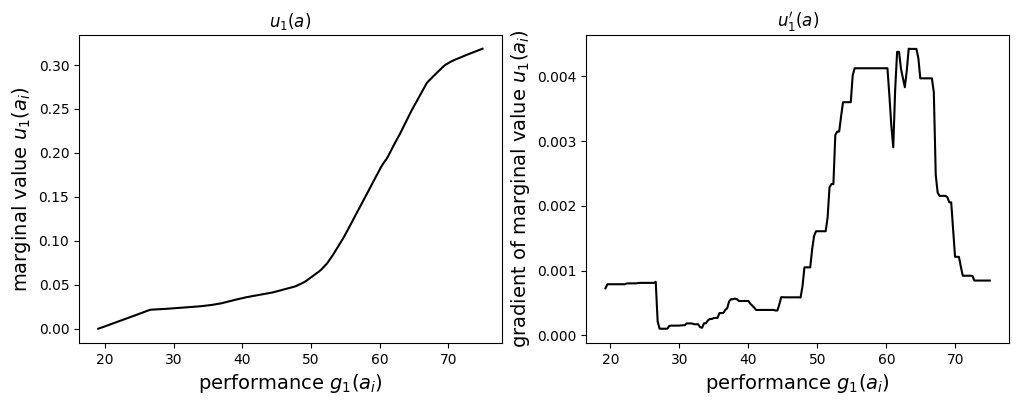

criterion Saving accounts:


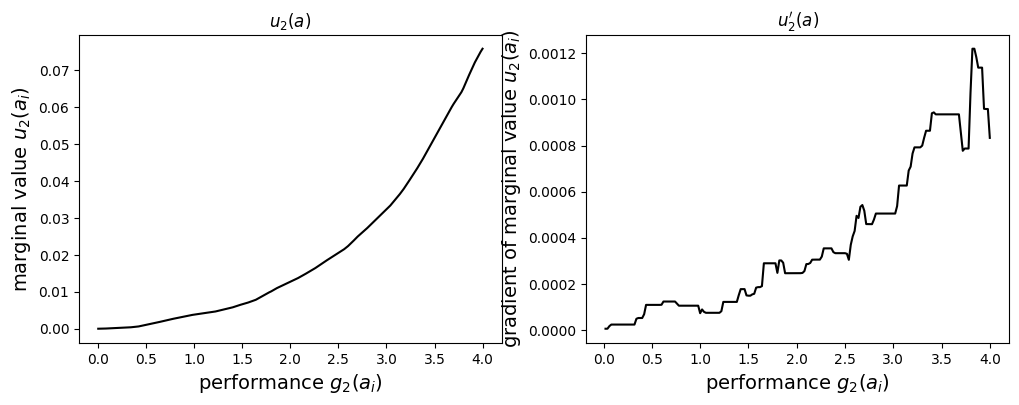

criterion Checking account:


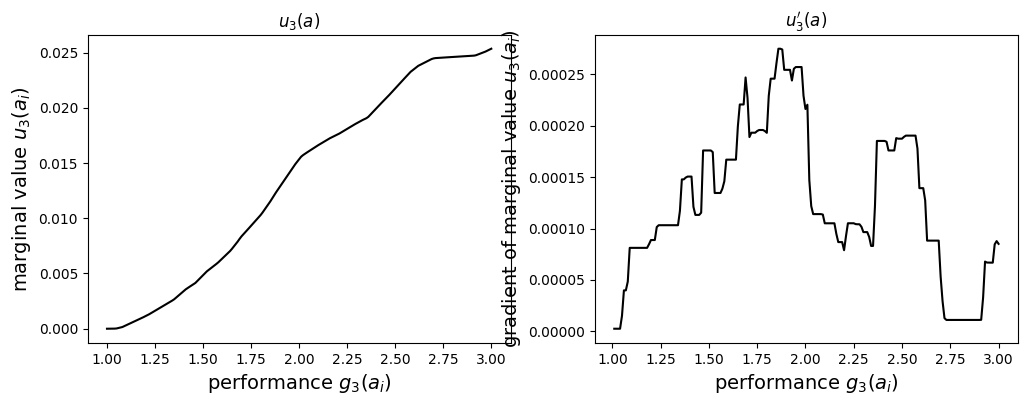

criterion Credit amount:


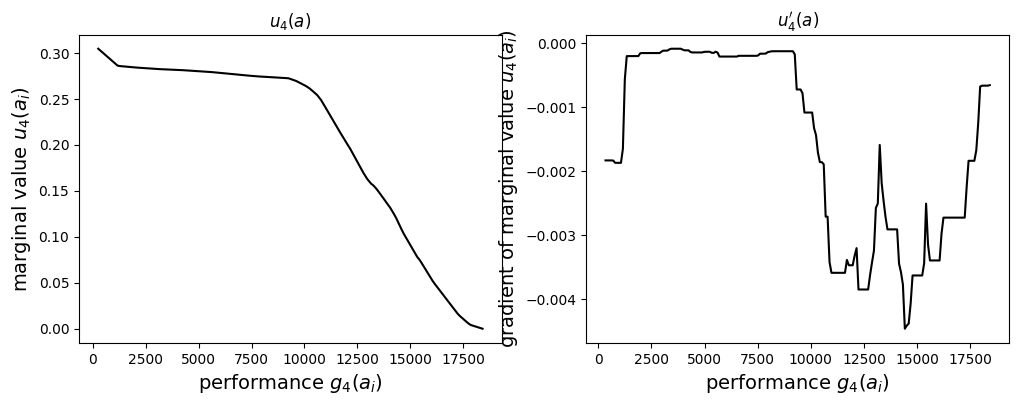

criterion Duration:


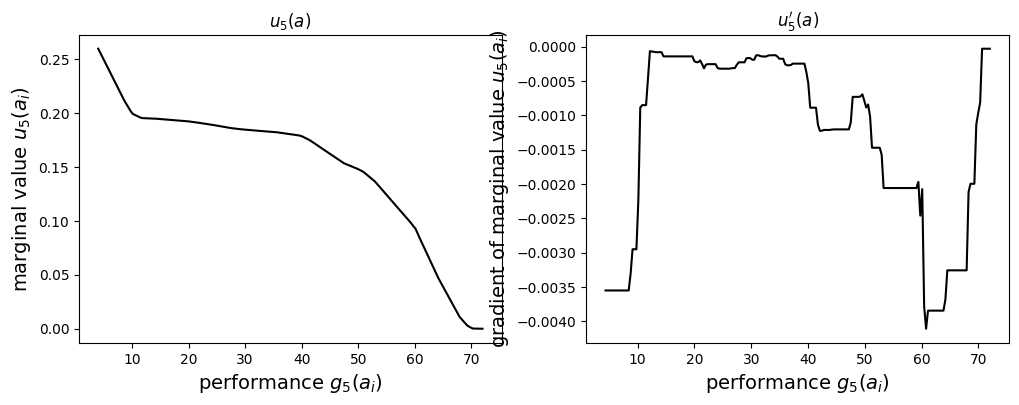

criterion Purpose:


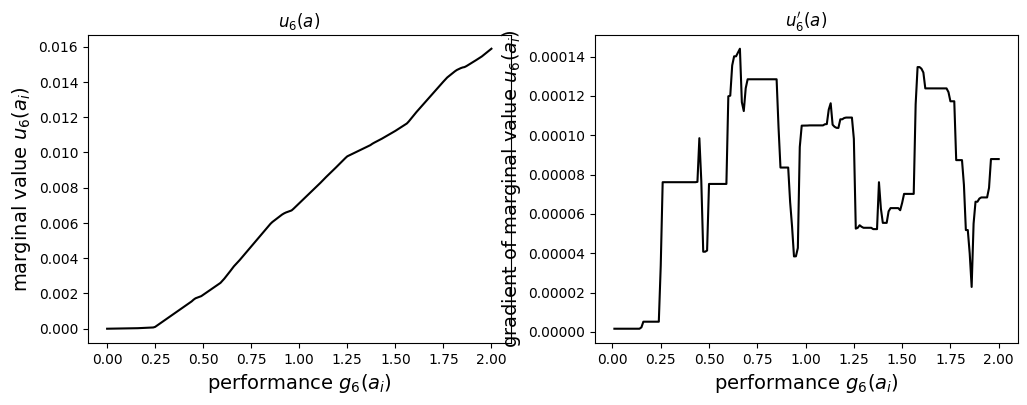

In [54]:
def inverse_xs(xs, scaler, feature_idx, num_criteria):
    """Inverse transform xs values for a single feature back to original scale."""
    dummy = np.zeros((len(xs), num_criteria))
    dummy[:, feature_idx] = xs
    return scaler.inverse_transform(dummy)[:, feature_idx]

print("marginal value functions and their gradients:")
for i in range(num_criteria):
    criterion_number = i + 1
    xs_original = inverse_xs(xs, scaler, i, num_criteria)
    
    is_reverse = data.columns[i] in ["Credit amount", "Duration"]
    if is_reverse:
        xs_original = -xs_original[::-1]   
        outs_i      = outs[::-1, i]        
        outs_grad   = outs_i[1:] - outs_i[:-1]
    else:
        outs_i    = outs[:, i]
        outs_grad = outs[1:, i] - outs[:-1, i]

    print(f"criterion {data.columns[i]}:")
    fig = plt.figure(figsize=(12, 4))

    ax = fig.add_subplot(121)
    ax.set_title(f'$u_{criterion_number}(a)$')
    ax.plot(xs_original, outs_i, color="black")
    ax.set_ylabel(f"marginal value $u_{criterion_number}(a_i)$", fontsize=14)
    ax.set_xlabel(f"performance $g_{criterion_number}(a_i)$", fontsize=14)

    ax = fig.add_subplot(1, 2, 2)
    ax.set_title(f"$u_{criterion_number}'(a)$")
    ax.plot(xs_original[1:], outs_grad, color="black")
    ax.set_ylabel(f"gradient of marginal value $u_{criterion_number}(a_i)$", fontsize=14)
    ax.set_xlabel(f"performance $g_{criterion_number}(a_i)$", fontsize=14)
    plt.show()

#### weights for categories

           category  weight
0               Age  0.3184
1   Saving accounts  0.0759
2  Checking account  0.0253
3     Credit amount  0.3046
4          Duration  0.2599
5           Purpose  0.0159


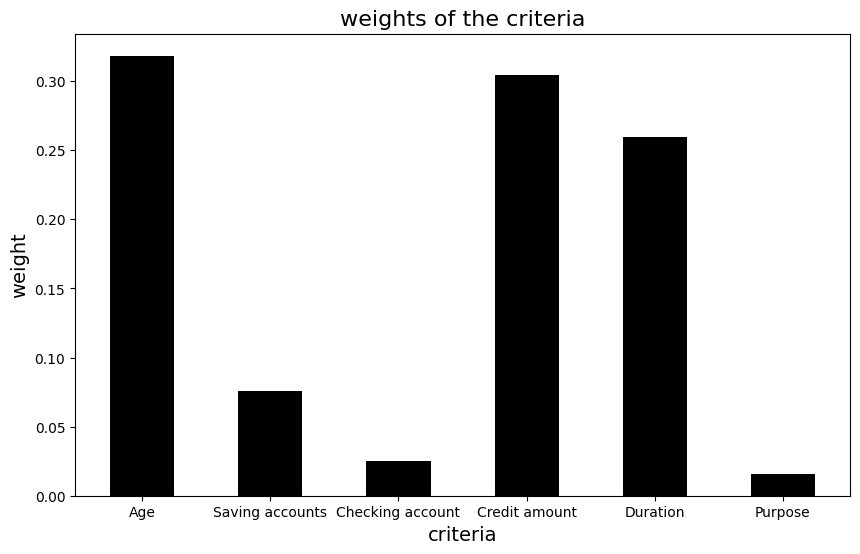

In [55]:
names = data.columns[:num_criteria]
weights = []
for i in range(num_criteria):
    weights.append(outs[-1][i]) 
df_weights = pd.DataFrame({"category": names, "weight" : weights})
print(round(df_weights,4))
#barplot of the weights
plt.figure(figsize=(10,6))
plt.bar(df_weights["category"], round(df_weights["weight"],4), color="black", width=0.5)
plt.xlabel("criteria", fontsize=14)
plt.ylabel("weight", fontsize=14)
plt.title("weights of the criteria", fontsize=16)
plt.show()

`age` , `credit account`, and `duration` seem to be the biggest indicators of the correct class, criterias like `checking account` and `purpose` have nearly 0 meaning for the class predictions

Using 800 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 800/800 [00:34<00:00, 22.97it/s]
/tmp/ipykernel_44096/79308470.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


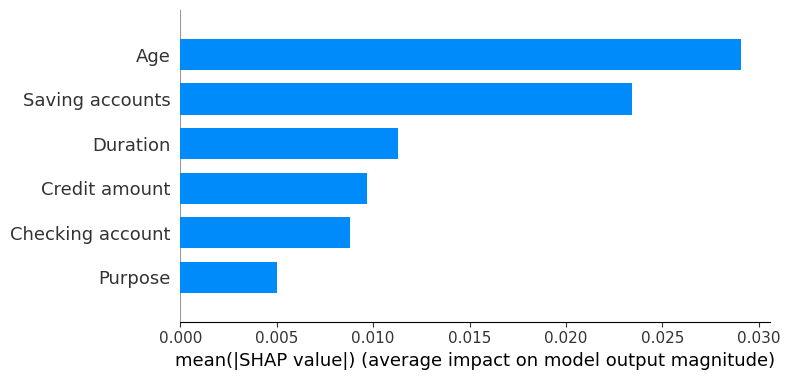

In [ ]:
import shap
import numpy as np

# 1. Wrap model 
def model_predict(x_np):
    with torch.no_grad():
        x_tensor = torch.tensor(x_np, dtype=torch.float32)
        output = model(x_tensor)
    return output.cpu().numpy()

# 2. Pass numpy arrays to SHAP
X_train_np = X_train_tensor.cpu().numpy()

explainer = shap.KernelExplainer(model_predict, X_train_np)
shap_values = explainer.shap_values(X_train_np)

shap.summary_plot(
    shap_values,
    X_train_np,
    feature_names=data.columns[:num_criteria].tolist(),
    plot_type="bar"
)

we can also check the importance of features what is sth slightly different and we can see it clearly.

It answers the question how much each criterion contributes to the model's output on average across the training set. 

porpose stays the least important feature, age is still most important, other features importance order is shuffeled comapred to weights. also proportions of all criterais are different

#### auc curve

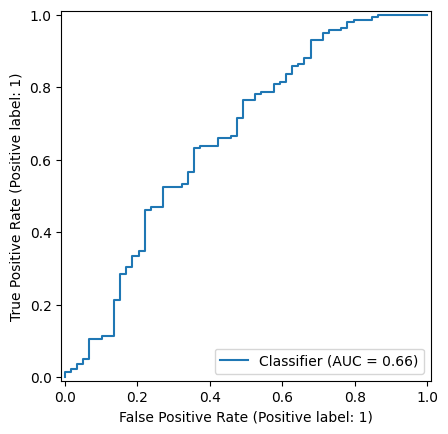

In [ ]:
#### AUC curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, outputs.cpu().numpy(), pos_label=1)

#### confusion matrix

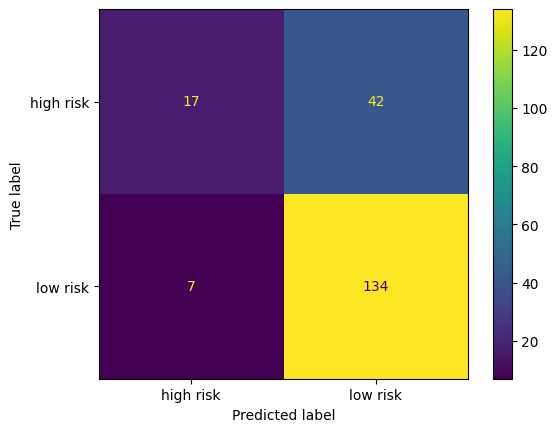

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions_default,
    labels=[0, 1],
    display_labels=[labels_map[0], labels_map[1]]
)

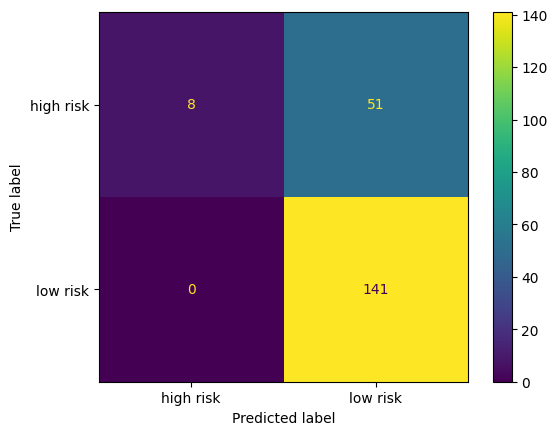

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions_optimal,
    labels=[0, 1],
    display_labels=[labels_map[0], labels_map[1]]
)

as you can see in case of **deafult predictions** the model deals quite well with class low risk(good), and a little bit worse with bad - it often predicsts majority class.

for **improved preictions** this is even worse, but overall accuracy and F1 are higher

depending on ones needs any level of the threshold could be better.

## 2.1

In [ ]:
# anylysis of selected alternatives for not changed threshold
# Select 3 alternatives 

with torch.no_grad():
    test_tensor = torch.Tensor(X_test).squeeze(1)
    test_outputs = model(test_tensor).squeeze().cpu().numpy()

test_preds = (test_outputs > 0 ).astype(int)

idx_A = np.argmax(test_outputs)  # Alternative 1 - best classified (most positive output)

# Alternative 2 - closest to decision boundary (seems therefore intresting)
idx_B = np.argmin(np.abs(test_outputs ))

# Alternative 3 - first misclassified (mybe we will explain what failed)
misclassified = np.where(test_preds != y_test)[0]
idx_C = misclassified[-4]
 

selected = {'A': idx_A, 'B': idx_B, 'C': idx_C}
label_map = {1: 'low risk', 0: 'high risk'}

for name, idx in selected.items():
    out = test_outputs[idx]
    cls = int(out > 0)

In [ ]:
# show those alternatives
print("\nSelected alternatives in order A (alternative with highest utility), B(alternative with lowest utiity), C(first misclassifiesd alternative):")
display(data.iloc[[idx_A, idx_B, idx_C]])


Selected alternatives in order A (alternative with highest utility), B(alternative with lowest utiity), C(first misclassifiesd alternative):


,Age,Saving accounts,Checking account,Credit amount,Duration,Purpose,credit_risk
106,39,0,3,-6458,-18,0,0
99,36,4,2,-7057,-20,0,1
193,29,0,3,-2108,-6,0,1


### Explain why the decision was made for the 3 selected alternatives

green bars show the marginal utility contributions u_i(a) of the criteria for each alternative, while the gray bars show the weights w_i of the criteria.
the text on the right of each bar shows the marginal utility value u_i(a) and the original criterion value g_i(a) for the alternative.


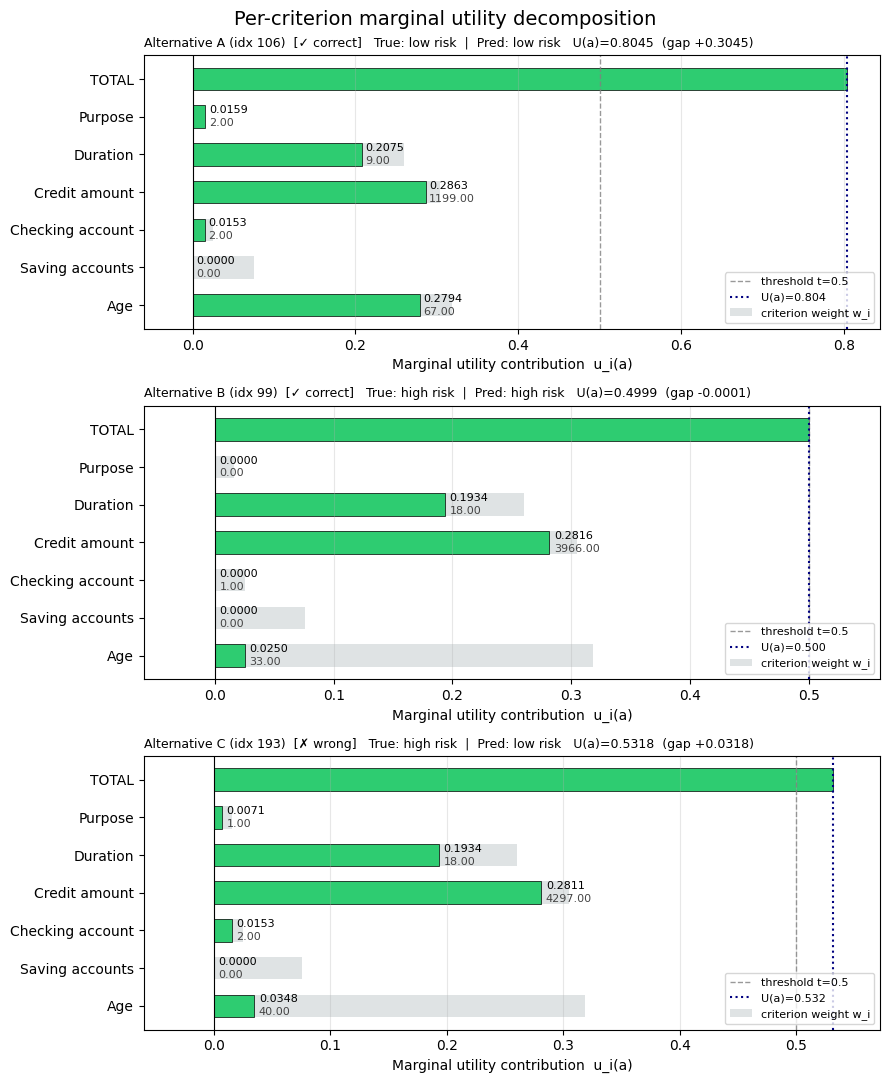

In [ ]:
# helpers
_feat_names = list(data.columns[:num_criteria])
_negated     = {"Credit amount", "Duration"}   
_X_2d        = X_test.reshape(-1, num_criteria)                   
_X_inv       = scaler.inverse_transform(_X_2d)                     
# restore original sign for display
_X_orig = _X_inv.copy()
for _i, _col in enumerate(_feat_names):
    if _col in _negated:
        _X_orig[:, _i] = -_X_inv[:, _i]

_weights = outs[-1].copy()   # w_i = u_i(x_max), sum = 1

def _get_utils(x_scaled_1d):
    """Look up per-criterion marginal utilities from the pre-computed outs table."""
    idx = np.clip(np.round(x_scaled_1d * 200).astype(int), 0, 200)
    return np.array([outs[idx[i], i] for i in range(num_criteria)])



for alt_name, idx in selected.items():
    x_sc   = _X_2d[idx]
    x_or   = _X_orig[idx]
    u_vals = _get_utils(x_sc)
    total  = u_vals.sum()
    pred   = int(test_outputs[idx] > 0)
    true_  = int(y_test[idx])


# plots 
fig, axes = plt.subplots(3, 1, figsize=(9, 11))
fig.suptitle('Per-criterion marginal utility decomposition', fontsize=14)
print("green bars show the marginal utility contributions u_i(a) of the criteria for each alternative, while the gray bars show the weights w_i of the criteria.")
print("the text on the right of each bar shows the marginal utility value u_i(a) and the original criterion value g_i(a) for the alternative.")

for ax, (alt_name, idx) in zip(axes, selected.items()):
    x_sc    = _X_2d[idx]
    x_or    = _X_orig[idx]
    u_vals  = _get_utils(x_sc)
    total   = u_vals.sum()
    pred    = int(test_outputs[idx] > 0)
    true_   = int(y_test[idx])
    correct = pred == true_

    _feat_names_ext = _feat_names + ['TOTAL']          
    u_vals_ext     = np.append(u_vals, total) 
    _weights_ext    = np.append(_weights, 0)  


    colors = ['#2ecc71']
    bars_w = ax.barh(_feat_names_ext, _weights_ext, color='#95a5a6',
                    alpha=0.3, height=0.6, label='criterion weight w_i')
    bars   = ax.barh(_feat_names_ext, u_vals_ext, color=colors,
                     edgecolor='black', linewidth=0.5, height=0.6)

    ax.axvline(0,     color='black', linewidth=0.8)
    ax.axvline(0.5,   color='gray',  linewidth=1.0, linestyle='--',
               alpha=0.8, label='threshold t=0.5')
    ax.axvline(total, color='navy',  linewidth=1.5, linestyle=':',
               label=f'U(a)={total:.3f}')

    x_max = max(total + 0.04, _weights_ext.max() + 0.06, 0.56)
    ax.set_xlim(-0.06, x_max)

    for bar, u_val, orig_val in zip(bars, u_vals_ext, x_or):
        bw     = bar.get_width()
        y_mid  = bar.get_y() + bar.get_height() / 2
        offset = 0.004
        ha     = 'left'
        x_pos  = bw + offset
        ax.text(x_pos, y_mid + 0.17, f'{u_val:.4f}',
                ha=ha, va='center', fontsize=8)
        ax.text(x_pos, y_mid - 0.17, f'{orig_val:.2f}',
                ha=ha, va='center', fontsize=8, color='#444444')

    verdict = '✓ correct' if correct else '✗ wrong'
    ax.set_title(
        f'Alternative {alt_name} (idx {idx})  [{verdict}]   '
        f'True: {labels_map[true_]}  |  Pred: {labels_map[pred]}   '
        f'U(a)={total:.4f}  (gap {total - 0.5:+.4f})',
        fontsize=9, loc='left'
    )
    ax.set_xlabel('Marginal utility contribution  u_i(a)')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


for alternative `A` (alternative with highest utility af all)its obvious that it should be classified to the low risk class, all of the performances on all criterions are the  best possible. only age seems to be lowering its score. In fact persons age is 61 and to attain even higher score he/she would have to be even older. also little saving accounts lower the score

alternatives `B` and `C` are alternatives that are accordingly clossest to decision boundary, and some intresting misclassified example

both are similar - only difference is slightly higher score for C was age, credit amount and duration `C` - it made that alternative classify as high risk. 

alternative `B` was really close to low risk class. small improvement on any criteria would make it classify correctly

### Take 3 alternatives and say what the minimum change to a single criterion should be done so that the option is classified into a different class

####  Try to answer this question in an analytical way based only on the values of the model parameters and explain why such a change is minimal (without sampling).

In [ ]:
feat_names  = list(data.columns[:num_criteria])
negated     = {"Credit amount", "Duration"}
X_2d        = X_test.reshape(-1, num_criteria)
X_inv       = scaler.inverse_transform(X_2d)
X_orig      = X_inv.copy()
for ci, col in enumerate(feat_names):
    if col in negated:
        X_orig[:, ci] = -X_inv[:, ci]

criterion_weights = outs[-1].copy()

def get_utils(x_scaled_1d):
    idx = np.clip(np.round(x_scaled_1d * 200).astype(int), 0, 200)
    return np.array([outs[idx[i], i] for i in range(num_criteria)])


# Extract parameters
spread  = model.method_instance.monotonic_layer.criterion_layer_spread
combine = model.method_instance.monotonic_layer.criterion_layer_combine
slope   = model.method_instance.monotonic_layer.activation_function.slope

Ws = spread.compute_weight().detach().numpy()   # (H, C)
B  = spread.compute_bias().detach().numpy()     # (H, C)
Wc = combine.compute_weight().detach().numpy()  # (H, C)

# Analytic u_raw(x, i)
def lhs(z):
    return np.where(z < 0,  slope * z,
           np.where(z <= 1, z,
                             1.0 + slope * (z - 1.0)))

def u_raw(x_val, i):
    z = (x_val + B[:, i]) * Ws[:, i]
    return float(np.dot(Wc[:, i], lhs(z)))

def analytical_flip_pure(x_scaled_1d):
    """
    The function answers: "what is the smallest change to a single criterion that would flip the model's prediction to the boundary of 0.5
    1. Compute current utility — for each criterion i, it analytically evaluates the marginal utility u_raw(x_i) using the model's weight tensors (Spread/Combine) and the LeakyHardSigmoid activation, without running the model.
    2.Normalize & find the gap — utilities are normalized to [0,1] using u(0) and u(1) as anchors. The gap = 0.5 - total_U is how far the current score is from the decision boundary.
    3.Solve per criterion — for each criterion independently, it finds the new value new_x such that shifting that one criterion's utility by the full gap would move the total score exactly to 0.5. It does this by finding the piecewise-linear segment containing the solution and linearly interpolating within it.
    """
    # Extract weight tensors
    spread    = model.method_instance.monotonic_layer.criterion_layer_spread
    combine   = model.method_instance.monotonic_layer.criterion_layer_combine
    act_slope = model.method_instance.monotonic_layer.activation_function.slope

    Ws = spread.compute_weight().detach().numpy()   # (H, C)  >= 0
    B  = spread.compute_bias().detach().numpy()     # (H, C)
    Wc = combine.compute_weight().detach().numpy()  # (H, C)  >= 0
    H, C = Ws.shape

    # Analytic LeakyHardSigmoid + u_raw 
    def lhs(z):
        return np.where(z < 0,  act_slope * z,
               np.where(z <= 1, z,
                                1.0 + act_slope * (z - 1.0)))

    def u_raw(x_val, i):
        z = (x_val + B[:, i]) * Ws[:, i]
        return float(np.dot(Wc[:, i], lhs(z)))

    # Normalization constants
    u0    = np.array([u_raw(0.0, i) for i in range(C)])
    u1    = np.array([u_raw(1.0, i) for i in range(C)])
    denom = (u1 - u0).sum()

    # Current utility & gap 
    u_cur   = np.array([u_raw(x_scaled_1d[i], i) for i in range(C)])
    total_U = ((u_cur - u0) / denom).sum()
    gap     = 0.5 - total_U

    # Solve per criterion 
    per = {}
    for i in range(C):
        target_raw = u_cur[i] + gap * denom

        # Check reachability within [0,1]
        u_lo_bound = min(u0[i], u1[i])
        u_hi_bound = max(u0[i], u1[i])
        if not (u_lo_bound - 1e-9 <= target_raw <= u_hi_bound + 1e-9):
            continue

        # Breakpoints in [0,1]
        bps = {0.0, 1.0}
        for k in range(H):
            if Ws[k, i] > 1e-8:
                for bp in (-B[k, i], 1.0 / Ws[k, i] - B[k, i]):
                    if 0.0 < bp < 1.0:
                        bps.add(float(bp))
        bps = sorted(bps)

        # The segment containing the solution
        x_cur = x_scaled_1d[i]
        new_x = None
        for s in range(len(bps) - 1):
            x_lo, x_hi = bps[s], bps[s + 1]

            # Skip segments in the wrong direction
            if gap >= 0 and x_hi < x_cur - 1e-9: continue
            if gap <  0 and x_lo > x_cur + 1e-9: continue

            ul, uh = u_raw(x_lo, i), u_raw(x_hi, i)
            if not (min(ul, uh) - 1e-9 <= target_raw <= max(ul, uh) + 1e-9):
                continue

            # Linear interpolation within segment (exact for piecewise-linear)
            if abs(uh - ul) < 1e-12:
                candidate = x_cur
            else:
                t = (target_raw - ul) / (uh - ul)
                candidate = float(np.clip(x_lo + t * (x_hi - x_lo), 0.0, 1.0))

            if gap >= 0 and candidate >= x_cur - 1e-9:
                new_x = candidate; break
            if gap <  0 and candidate <= x_cur + 1e-9:
                new_x = candidate; break

        if new_x is None:
            continue

        x_mod    = x_scaled_1d.copy(); x_mod[i] = new_x
        inv0_v   = scaler.inverse_transform(x_scaled_1d.reshape(1,-1)).flatten()
        inv1_v   = scaler.inverse_transform(x_mod.reshape(1,-1)).flatten()
        d_or     = inv1_v[i] - inv0_v[i]
        if feat_names[i] in negated:
            d_or = -d_or

        per[i] = dict(delta_sc=new_x - x_cur, delta_or=d_or, new_sc=new_x)

    if not per:
        return None, {}
    best_i = min(per, key=lambda k: abs(per[k]['delta_sc']))
    return best_i, per



def sampling_flip(x_scaled_1d, crit_i, n_steps=20000):
    with torch.no_grad():
        pred0 = int(model(torch.tensor(x_scaled_1d, dtype=torch.float32).view(1,1,-1)).item() > 0)
    direction = +1 if pred0 == 0 else -1
    for step in range(1, n_steps + 1):
        delta = direction * step / n_steps
        new_v = x_scaled_1d[crit_i] + delta
        if not (0.0 <= new_v <= 1.0):
            break
        x_try         = x_scaled_1d.copy()
        x_try[crit_i] = new_v
        with torch.no_grad():
            new_pred = int(model(torch.tensor(x_try, dtype=torch.float32).view(1,1,-1)).item() > 0)
        if new_pred != pred0:
            inv0 = scaler.inverse_transform(x_scaled_1d.reshape(1,-1)).flatten()
            inv1 = scaler.inverse_transform(x_try.reshape(1,-1)).flatten()
            d_or = inv1[crit_i] - inv0[crit_i]
            if feat_names[crit_i] in negated:
                d_or = -d_or
            return delta, d_or
    return None, None


flip_results = {}
for alt, idx in selected.items():
    x       = X_2d[idx]
    bi, per = analytical_flip_pure(x)

    samp_per = {}
    for i in range(num_criteria):
        sd, od = sampling_flip(x, i)
        if sd is not None:
            samp_per[i] = dict(samp_sc=sd, samp_or=od)

    best_samp_i = min(samp_per, key=lambda k: abs(samp_per[k]['samp_sc'])) if samp_per else None
    sd = samp_per[best_samp_i]['samp_sc'] if best_samp_i is not None else None
    od = samp_per[best_samp_i]['samp_or'] if best_samp_i is not None else None

    flip_results[alt] = dict(idx=idx, best_i=bi, per=per,
                              samp_sc=sd, samp_or=od,
                              samp_per=samp_per, best_samp_i=best_samp_i)


In [ ]:
print("\nAnalytic flip results (minimum change to flip prediction):")
for alt, res in flip_results.items():
    print("="*80)
    idx, best_i, per = res['idx'], res['best_i'], res['per']
    x_sc  = X_2d[idx]
    x_or  = X_orig[idx]
    total = get_utils(x_sc).sum()
    pred  = int(test_outputs[idx] > 0)

    display(pd.DataFrame([{
        'Alternative': alt, 'idx': idx,
        'Prediction': labels_map[pred],
        'U(a)': round(float(total), 4),
        'gap to t=0.5': round(float(0.5 - total), 4),
        'Best criterion': feat_names[best_i] if best_i is not None else '—',
    }]).set_index('Alternative'))

    rows = []
    for i in range(num_criteria):
        if i in per:
            r = per[i]
            rows.append({'Criterion': feat_names[i],
                         'Δ scaled':    round(float(r['delta_sc']), 6),
                         'Δ original':  round(float(r['delta_or']), 3),
                         'Feasible': 'yes',
                         'Best': '<- best' if i == best_i else ''})
        else:
            rows.append({'Criterion': feat_names[i],
                         'Δ scaled': None, 'Δ original': None,
                         'Feasible': 'no (out of range)', 'Best': ''})

    df = pd.DataFrame(rows).set_index('Criterion')

    def highlight_best(row):
        return ['font-weight: bold; background-color: #fff3cd'
                if row['Best'] == '<- best' else '' for _ in row]

    display(df.style.apply(highlight_best, axis=1)
              .format({'Δ scaled': '{:+.6f}', 'Δ original': '{:+.3f}',
                       'Local slope': '{:.6f}'}, na_rep='—'))

    if best_i is not None:
        r = per[best_i]
        display(pd.DataFrame([{
            'Criterion':      feat_names[best_i],
            'Current value':  round(float(x_or[best_i]), 3),
            'Required value': round(float(x_or[best_i] + r['delta_or']), 3),
            'Δ original':     round(float(r['delta_or']), 3),
            'Δ scaled':       round(float(r['delta_sc']), 6),
        }]).style.set_caption(f'Alt {alt} — minimum flip change').hide(axis='index'))




Analytic flip results (minimum change to flip prediction):


,idx,Prediction,U(a),gap to t=0.5,Best criterion
Alternative,,,,,
A,106,low risk,0.8045,-0.3045,—


,Δ scaled,Δ original,Feasible,Best
Criterion,,,,
Age,—,—,no (out of range),
Saving accounts,—,—,no (out of range),
Checking account,—,—,no (out of range),
Credit amount,—,—,no (out of range),
Duration,—,—,no (out of range),
Purpose,—,—,no (out of range),


,idx,Prediction,U(a),gap to t=0.5,Best criterion
Alternative,,,,,
B,99,high risk,0.4999,0.0001,Duration


,Δ scaled,Δ original,Feasible,Best
Criterion,,,,
Age,+0.002843,+0.159,yes,
Saving accounts,+0.022393,+0.090,yes,
Checking account,+0.030011,+0.060,yes,
Credit amount,+0.003153,-57.298,yes,
Duration,+0.002274,-0.155,yes,<- best
Purpose,+0.113628,+0.227,yes,


Criterion,Current value,Required value,Δ original,Δ scaled
Duration,18.000000,17.845000,-0.155000,0.002274


,idx,Prediction,U(a),gap to t=0.5,Best criterion
Alternative,,,,,
C,193,low risk,0.5318,-0.0318,Age


,Δ scaled,Δ original,Feasible,Best
Criterion,,,,
Age,-0.355556,-19.911,yes,<- best
Saving accounts,—,—,no (out of range),
Checking account,—,—,no (out of range),
Credit amount,-0.355980,+6469.584,yes,
Duration,-0.400233,+27.216,yes,
Purpose,—,—,no (out of range),


Criterion,Current value,Required value,Δ original,Δ scaled
Age,40.000000,20.089000,-19.911000,-0.355556


some of the parameters seem to be beyond the allowable range for the parameter to allow flip. especailly for example with high confidence

#### Perform space sampling by slightly changing the evaluations of alternatives to get a different class. Do the results agree with theoretical predictions?


left plots- for each criterion, the minimum Δ_i change required to flip the class according to the analytical method (upper bars), and by sampling the model (bottom bars); orange lines are the criterions indicated as the closest to flip by both methods
 The line plots show how the model output changes when we vary the best criterion across its range, with vertical lines indicating the current value, the analytical flip point, and the sampled flip point (if found).


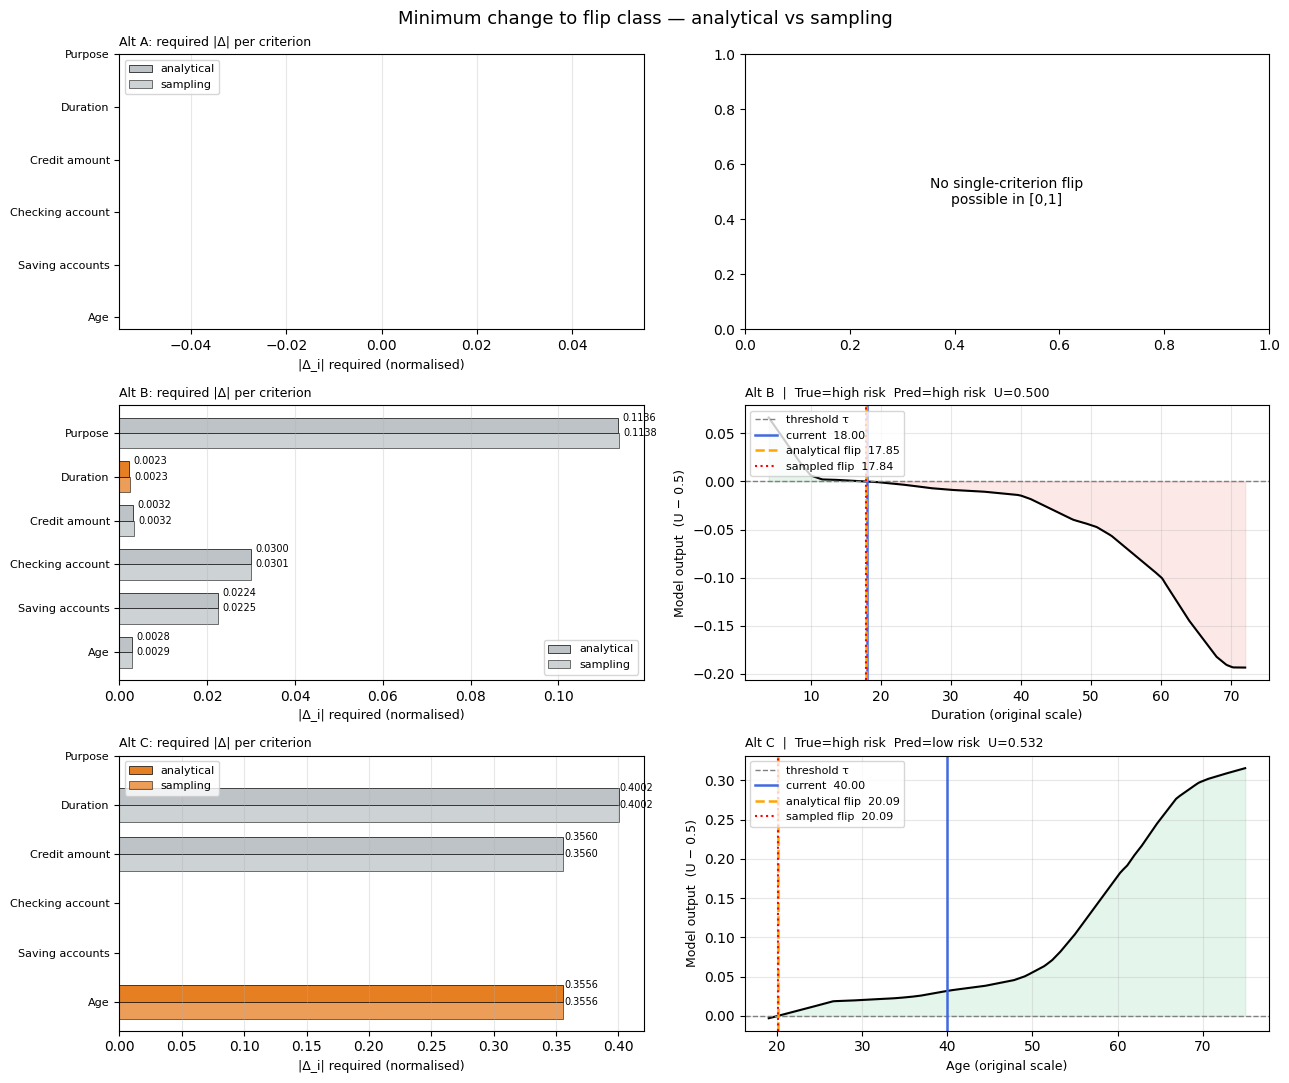

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
fig.suptitle('Minimum change to flip class — analytical vs sampling', fontsize=13)

scan_pts = 401
bar_h    = 0.35
y_pos    = np.arange(num_criteria)

print("left plots- for each criterion, the minimum Δ_i change required to flip the class according to the analytical method (upper bars), and by sampling the model (bottom bars); orange lines are the criterions indicated as the closest to flip by both methods" \
"\n The line plots show how the model output changes when we vary the best criterion across its range, with vertical lines indicating the current value, the analytical flip point, and the sampled flip point (if found).")

for row, (alt, res) in enumerate(flip_results.items()):
    ax_bar, ax_line = axes[row, 0], axes[row, 1]
    idx, best_i, per       = res['idx'], res['best_i'], res['per']
    samp_sc, samp_or       = res['samp_sc'], res['samp_or']
    samp_per, best_samp_i  = res['samp_per'], res['best_samp_i']
    x_sc  = X_2d[idx]
    x_or  = X_orig[idx]
    total = get_utils(x_sc).sum()
    pred  = int(test_outputs[idx] > 0)
    true_ = int(y_test[idx])

    # ── grouped bars ──────────────────────────────────────────────────────────
    anal_vals = [abs(per[i]['delta_sc'])              if i in per      else np.nan for i in range(num_criteria)]
    samp_vals = [abs(samp_per[i]['samp_sc'])          if i in samp_per else np.nan for i in range(num_criteria)]

    anal_colors = ['#e67e22' if i == best_i       else '#bdc3c7' for i in range(num_criteria)]
    samp_colors = ['#e67e22' if i == best_samp_i  else '#bdc3c7' for i in range(num_criteria)]

    ax_bar.barh(y_pos + bar_h, anal_vals, height=bar_h, color=anal_colors,
                edgecolor='black', linewidth=0.5, label='analytical')
    ax_bar.barh(y_pos,         samp_vals, height=bar_h, color=samp_colors,
                edgecolor='black', linewidth=0.5, label='sampling', alpha=0.75)

    ax_bar.set_yticks(y_pos + bar_h / 2)
    ax_bar.set_yticklabels(feat_names, fontsize=8)
    ax_bar.set_xlabel('|Δ_i| required (normalised)', fontsize=9)
    ax_bar.set_title(f'Alt {alt}: required |Δ| per criterion', fontsize=9, loc='left')
    ax_bar.legend(fontsize=8)
    ax_bar.grid(axis='x', alpha=0.3)

    for i, (av, sv) in enumerate(zip(anal_vals, samp_vals)):
        if not np.isnan(av):
            ax_bar.text(av + 0.001, i + bar_h + bar_h/2, f'{av:.4f}', va='center', fontsize=7)
        if not np.isnan(sv):
            ax_bar.text(sv + 0.001, i + bar_h/2,         f'{sv:.4f}', va='center', fontsize=7)

    # ── line plot (unchanged) ──────────────────────────────────────────────────
    if best_i is None:
        ax_line.text(0.5, 0.5, 'No single-criterion flip\npossible in [0,1]',
                     ha='center', va='center', transform=ax_line.transAxes)
        continue

    scan_sc_vals = np.linspace(0, 1, scan_pts)
    scan_or_vals, scan_out_vals = [], []
    for v in scan_sc_vals:
        xt = x_sc.copy(); xt[best_i] = v
        inv = scaler.inverse_transform(xt.reshape(1,-1)).flatten()
        scan_or_vals.append(-inv[best_i] if feat_names[best_i] in negated else inv[best_i])
        with torch.no_grad():
            scan_out_vals.append(model(torch.tensor(xt, dtype=torch.float32).view(1,1,-1)).item())

    scan_or_vals  = np.array(scan_or_vals)
    scan_out_vals = np.array(scan_out_vals)

    ax_line.fill_between(scan_or_vals, scan_out_vals, 0,
                         where=(scan_out_vals > 0),  alpha=0.12, color='#27ae60')
    ax_line.fill_between(scan_or_vals, scan_out_vals, 0,
                         where=(scan_out_vals <= 0), alpha=0.12, color='#e74c3c')
    ax_line.plot(scan_or_vals, scan_out_vals, color='black', linewidth=1.5)
    ax_line.axhline(0, color='gray', linewidth=1.0, linestyle='--', label='threshold τ')
    ax_line.axvline(x_or[best_i], color='royalblue', linewidth=1.8,
                    label=f'current  {x_or[best_i]:.2f}')

    r        = per[best_i]
    analyt_v = x_or[best_i] + r['delta_or']
    ax_line.axvline(analyt_v, color='orange', linewidth=1.8, linestyle='--',
                    label=f'analytical flip  {analyt_v:.2f}')

    if samp_or is not None:
        samp_v = x_or[best_i] + samp_or
        ax_line.axvline(samp_v, color='red', linewidth=1.5, linestyle=':',
                        label=f'sampled flip  {samp_v:.2f}')

    ax_line.set_xlabel(f'{feat_names[best_i]} (original scale)', fontsize=9)
    ax_line.set_ylabel('Model output  (U − 0.5)', fontsize=9)
    ax_line.set_title(
        f'Alt {alt}  |  True={labels_map[true_]}  Pred={labels_map[pred]}  U={total:.3f}',
        fontsize=9, loc='left')
    ax_line.legend(fontsize=8, loc='upper left')
    ax_line.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('2_1_min_change.png', dpi=150, bbox_inches='tight')
plt.show()


the choice of the criterion with the smallest change is in each case the same in theoretical and practical derivations

the amount by which the change must be done is also nearly the same. in NN UTA DIS method it is possible to evaluate exactly the needed change based only on model weights. This models was created with interpretability in mind 

###  Explain the predictions for these objects using at least one technique (SHAP, Individual Conditional Expectation)


  0%|          | 0/3 [00:00<?, ?it/s]

Alternative A — low risk


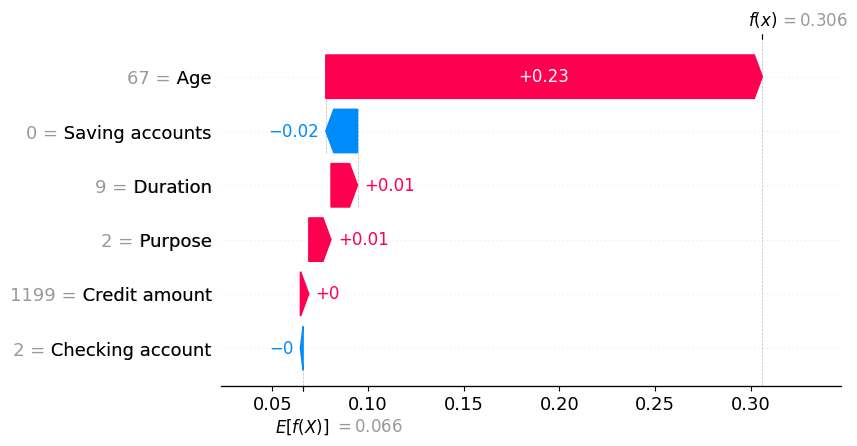

Alternative B — high risk


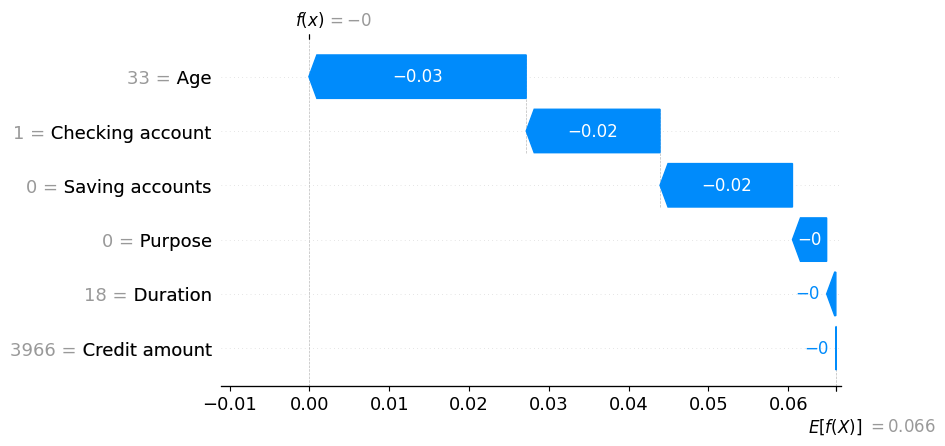

Alternative C — low risk


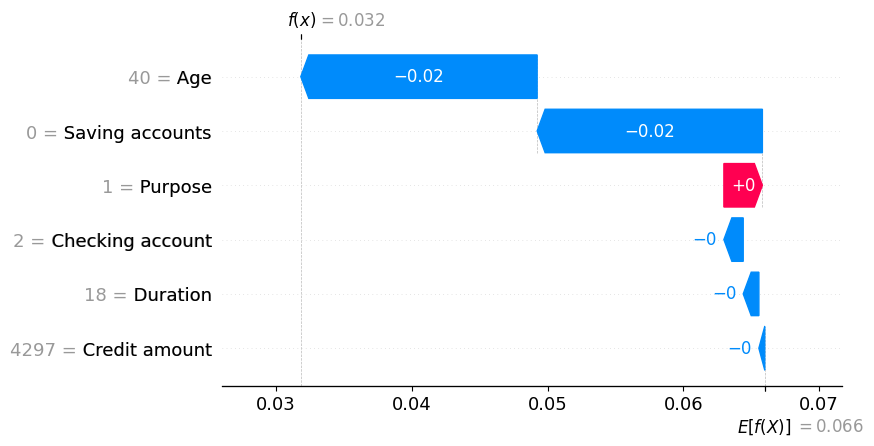

In [ ]:
import shap

def model_fn(X):
    t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
    with torch.no_grad():
        return model(t).numpy()

X_selected  = np.array([X_2d[selected[alt]] for alt in selected])
X_orig_sel  = np.array([X_orig[selected[alt]] for alt in selected])

explainer  = shap.KernelExplainer(model_fn, shap.sample(X_2d, 50))
shap_vals  = explainer.shap_values(X_selected, nsamples=500)

for i, alt in enumerate(selected):
    idx  = selected[alt]
    pred = int(test_outputs[idx] > 0)
    print(f"Alternative {alt} — {labels_map[pred]}")
    shap.waterfall_plot(shap.Explanation(
        values      = shap_vals[i],
        base_values = explainer.expected_value,
        data        = X_orig_sel[i],
        feature_names = feat_names
    ))


we can take a look at the predictions also from more universal point of view and explain it with shap. to check how each criterion contributed to the final result.

in this case shap checks for each feature, it all possible combinations of the remaining features and measures how much the prediction changes when that feature is added or removed

## 2.2 Interpretation of the model


### Based on the parameters obtained, can we say something about the user’s preferences?
Yes, directly from the weights and shapes of marginal utility functions that were already calculated. Higher weight = user values that criterion more. Steep slope region = where the user is most sensitive(slightest change in alternative changes the prediction the most).

we can for example see:
- `age`, `credit amount` and `duration` are the most important criterions
- change from value `3` to `4` in `Saving Accounts` is important for that criterion
- in `Age` after age 50 the marginal utility value rises really fastly.

Also we assume preferences of user in form of monotonicity constraints on criterias, so in this aspect we cant say anyting more

### What was the influence of the criteria? Are there any criteria that have no effect, or have a decisive influence?
as already written above the criteria influence can be read from weights of each criterion

plot derived before:
- 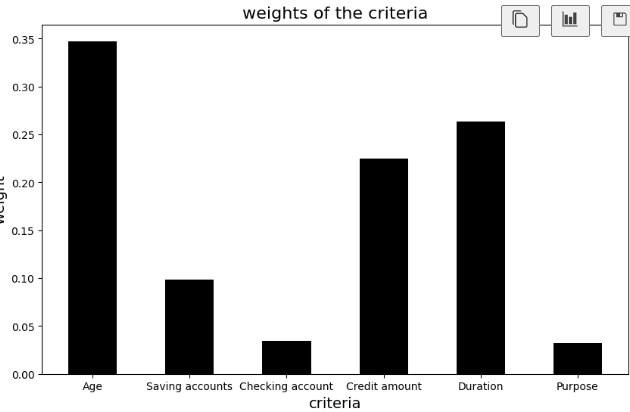

- a decisive influence has the criterion Age (especially for people after age 50 where there is steep increase in its value)
- other important factors are credit amout and urtaion

their high importance may be a result higher number of possible values in domain - and therefor it was easier to model those functions 

- purpose and chacking account have smallest impact with their summary impact way less than any other criterion 


### Are there any dependencies between the criteria?
 by architecture, there are none. UTA-DIS is an additive model with total utility beeing a weighted, normalized and shifted sum of marginal utility functions. Each marginal function is evaluated independently, so the model cannot represent interactions.

### What is the nature of the criterion, gain, cost, non-monotonic?
the architecture forces all functions to be non-decreasing (gain type criteria). Cost criteria  were handled by negating the raw values before training. Non-monotonic criteria are impossible with this architecture.

For this model we transformed some original features into a categories so they were monotonic logically(eg many purposes groupped into categories [irresponsible, necessary, ambitious]) and we also tested it by checking different combinations and correlation between the direction of criterion change and final classes.

and te resulting model that we prepared is:
- `Credit amount`, `Duration` - **cost type**
- `Age`, `saving accounts`, `checking account`, `purpose` - **gain type**
- some other criterions thrown out. eg because they were not satysfying the monotonicity in any way 

### Whether there are any preference thresholds? Are there any evaluations on criteria that are indifferent in terms of preferences?

there are some regions in marginal utility functions that seem close to beeing preference threshold. The regions with nearly flat marginal utility functions (where model does not care about the results) are:
- `duration` below around 25 months
- `saving accounts`  for 1, 2 or 3 accounts
- `age` below 50

### Interpret the model by at least one ( Partial Dependence Plot Permutation Feature Importance ...)



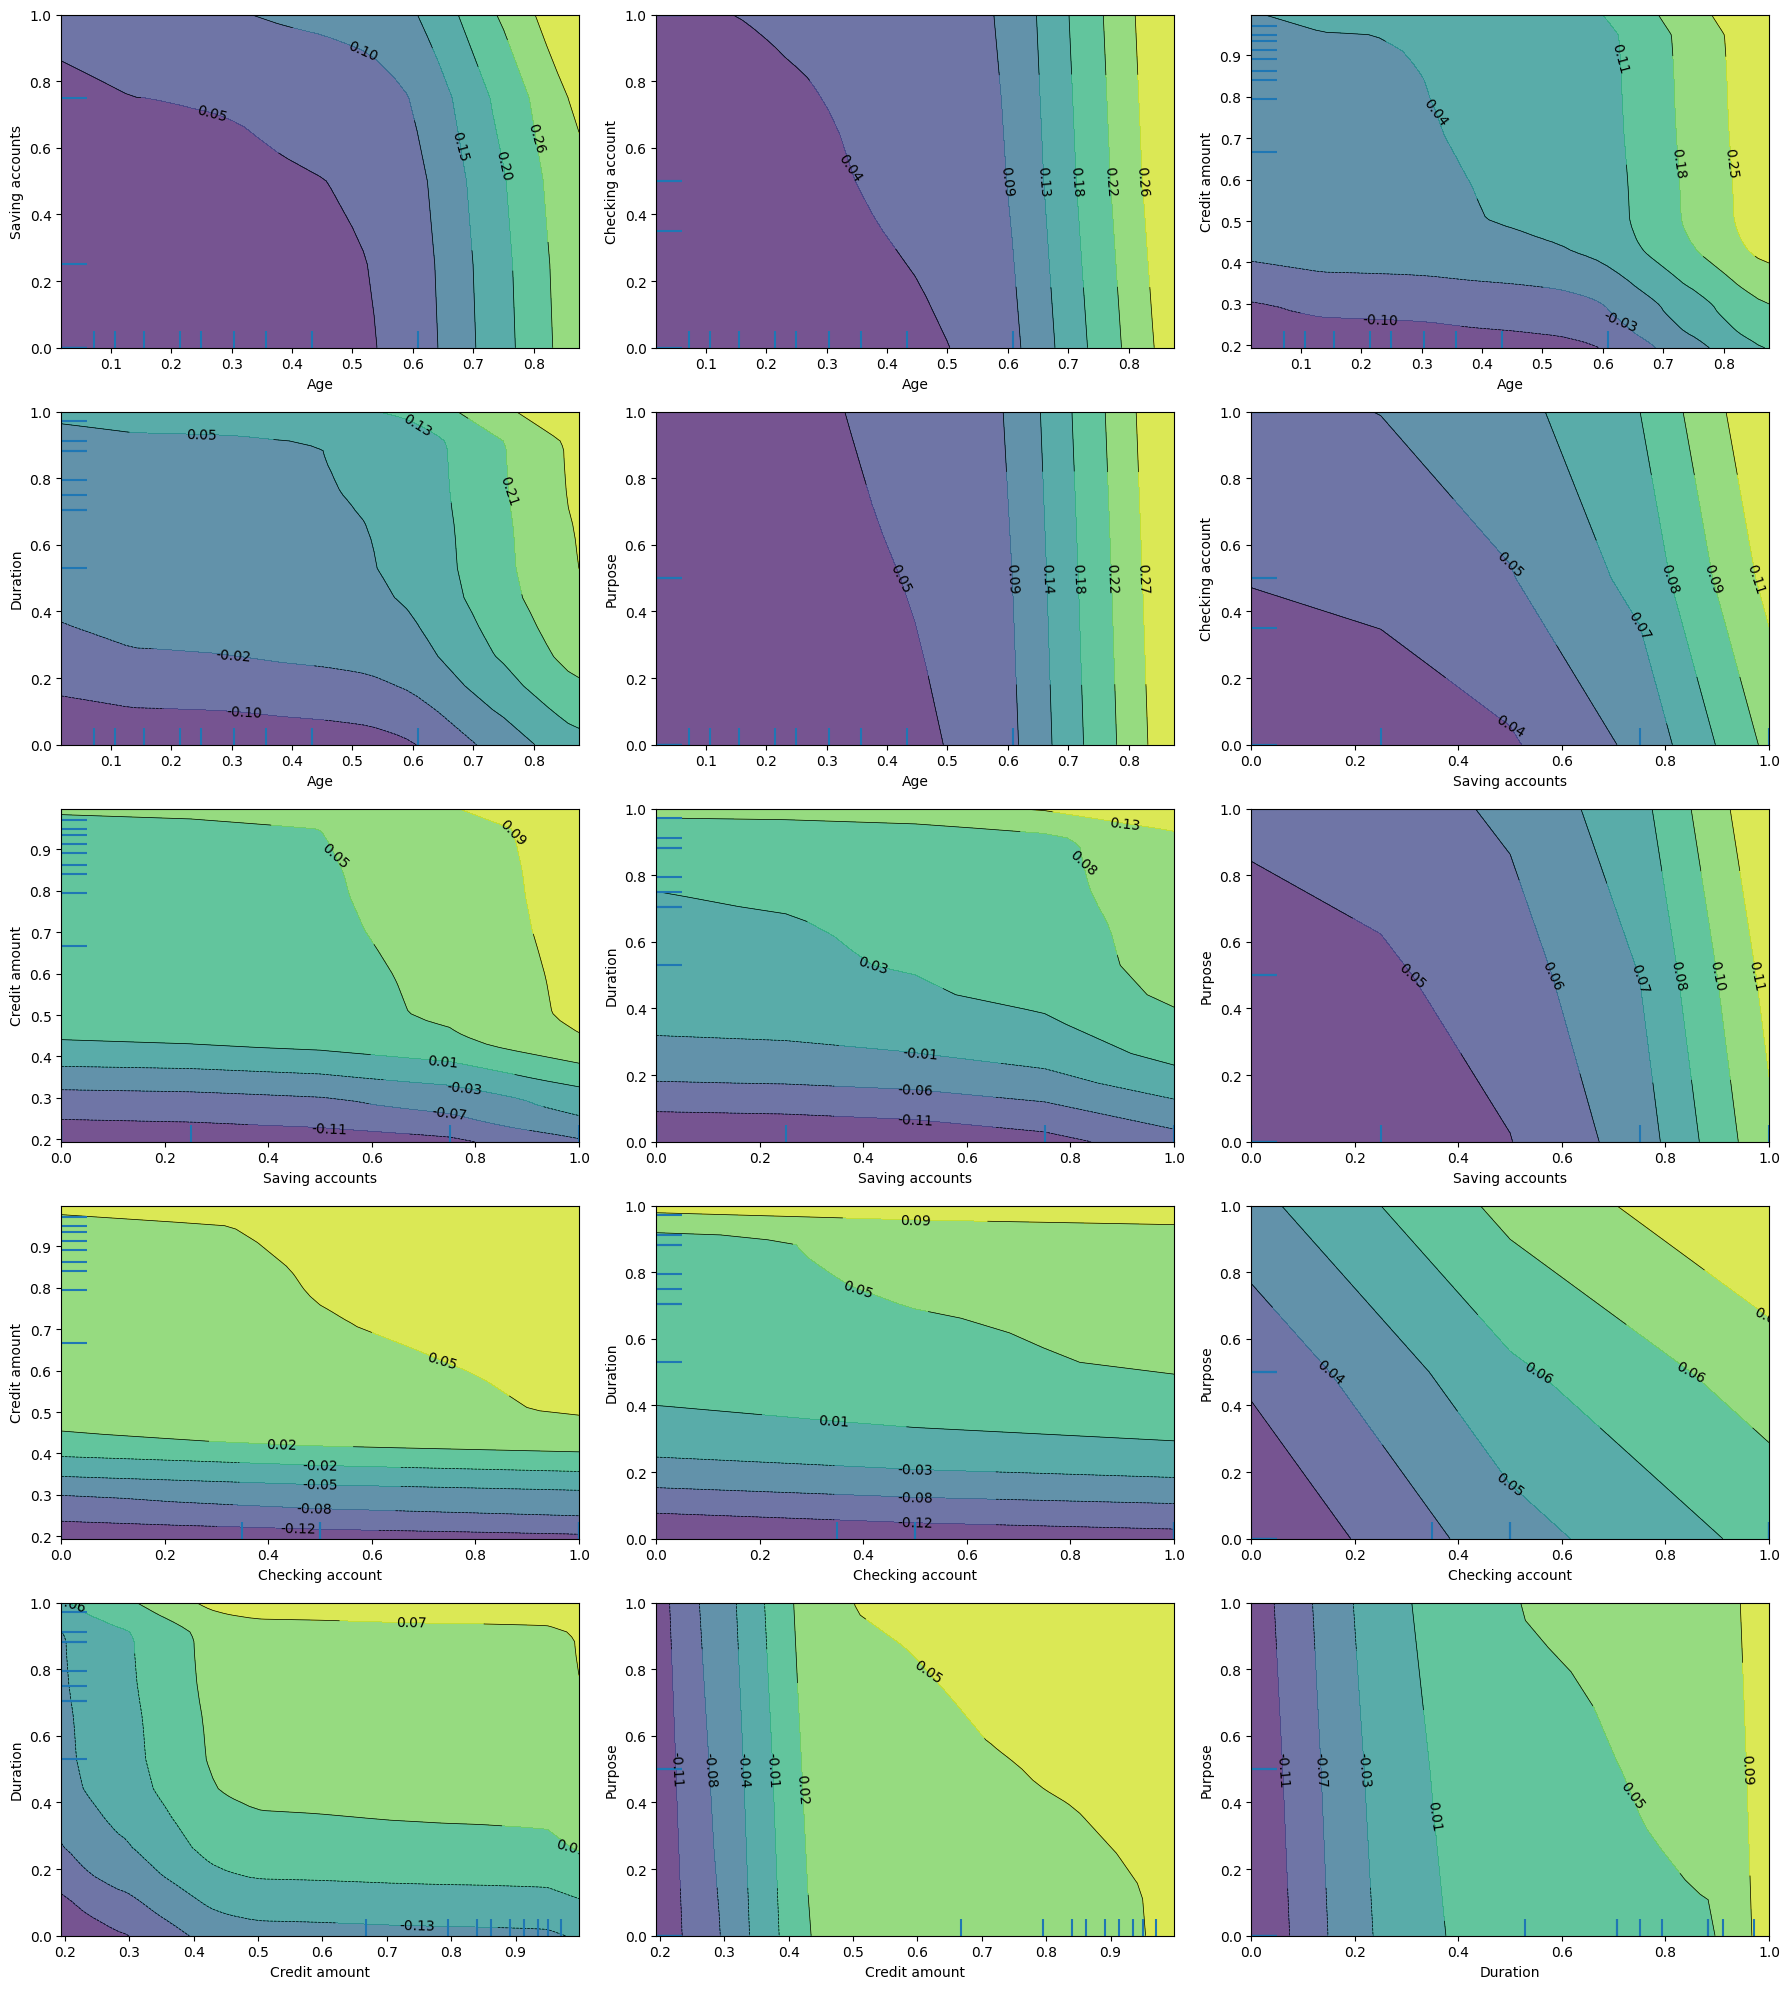

In [ ]:
from alibi.explainers.partial_dependence import plot_pd
from alibi.explainers import PartialDependence


def predict_fn(X):
    t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
    with torch.no_grad():
        return model(t).numpy()
    
pairs = [(i, j) for i in range(num_criteria)
                for j in range(i+1, num_criteria)]

pd_exp = PartialDependence(predictor=predict_fn,
                           feature_names=feat_names)

exp = pd_exp.explain(X_2d, features=pairs)
axes = plot_pd(exp, n_cols=3,)
axes.flatten()[0].get_figure().set_size_inches(18, 20)
plt.tight_layout()
plt.show()





we can see here : 
- No interactions between criteria - nearly parallel diagonal contours confirm the model is purely additive (no criterion dependencies).
- Monotonicity is also clearly visible - all plots increase toward top-right.
- Decision boundary runs diagonally - poor performance on one criterion can be compensated by another, characteristic for such model
- more focus on positive predictions (low risk class) - most of the area of those plots is for positive class - it confirms that its the majority class and that the model predicts it more